In [49]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from scipy.optimize import fmin
display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>.output_result { max-width:100% !important; }</style>"))
np.set_printoptions(edgeitems=30, linewidth=100000)
np.set_printoptions(formatter={'complex_kind': '{:.6f}'.format})

In [15]:
def Id(dim):
    return np.diag(np.ones(dim))

def vecId(dim):
    return Id(dim).flatten()

def dim_from_vectorized_op(vec_op):
    dim = np.sqrt(len(vec_op))
    if not dim.is_integer():
        raise ValueError("The vector is not a vectorization of a square matrix.")
    dim = int(dim)
    return dim

def dim_of_square_mat(mat):
    if not (np.shape(mat)[0]==np.shape(mat)[1]):
        raise ValueError('Input is not a square matrix.')
    return np.shape(mat)[0]

def den_mat_from_vectorized_op(vec_op):
    dim=dim_from_vectorized_op(vec_op)
    return vec_op.reshape((dim, dim),order='F')

def trace_of_vectorized_op(vec_op):
    dim=dim_from_vectorized_op(vec_op)
    return np.inner(vecId(dim),vec_op)

def calc_anti_hermitian(J):
    dim = dim_of_square_mat(J)
    J_dagger_J = np.matmul(np.transpose(np.conjugate(J)), J)
    return -1/2*(np.kron(Id(dim), J_dagger_J) + np.kron(np.transpose(J_dagger_J),Id(dim)))
    
def calc_jump_channel(J):
    return np.kron(np.conjugate(J),J)

def calc_hermitian(H):
    dim = dim_of_square_mat(H)
    return - 1j*(np.kron(Id(dim),H) - np.kron(np.transpose(H), Id(dim)))

def calc_Liouville(H, Jump_op_list):
    dim_H = dim_of_square_mat(H)
    Liouville = calc_hermitian(H)
    for J in Jump_op_list:
        dim_J = dim_of_square_mat(J)
        if not dim_H==dim_J:
            raise ValueError('The jump operators and the Hamiltonian do not have the same size.')
        
        Liouville = Liouville + calc_jump_channel(J)
        Liouville = Liouville + calc_anti_hermitian(J)
    return Liouville

In [16]:
def calc_steady_state(Liouville):
    rho_steady = sc.linalg.null_space(Liouville)

    shape_rho_steady = np.shape(rho_steady)
    num_steady_states = shape_rho_steady[1]
    
    if not num_steady_states==1:
        raise ValueError('We have '+str(num_steady_states)+' steady states.')
    
    rho_steady=rho_steady.flatten()
    rho_steady = rho_steady/trace_of_vectorized_op(rho_steady)
    
    return rho_steady

def calc_Drazin_inv(Liouville, vec_steady_state):
    dim=dim_from_vectorized_op(vec_steady_state)

    Drazin_inv = np.linalg.pinv(Liouville)
    projector = Id(dim**2) - np.outer(vec_steady_state,vecId(dim))
    Drazin_inv = np.matmul(projector,np.matmul(Drazin_inv,projector))
    return Drazin_inv


def calc_F_D_SNR(Liouville_Drazin_inv, current_op_list, ws, vec_steady_state):
    dim = dim_from_vectorized_op(vec_steady_state)

    if not len(ws) == len(current_op_list):
        raise ValueError('The number of jump channels and number of current coefficients do not match')
    
    sum_of_weighted_current_op = np.zeros((dim**2, dim**2))
    F = 0
    D = 0

    for idx in range(len(current_op_list)):
        sum_of_weighted_current_op = sum_of_weighted_current_op + ws[idx]*current_op_list[idx]
        
        F = F + ws[idx] * trace_of_vectorized_op(current_op_list[idx].dot(vec_steady_state))        
        D = D + (ws[idx]**2) * trace_of_vectorized_op(current_op_list[idx].dot(vec_steady_state))
        
    
    correction = 2 * trace_of_vectorized_op(np.matmul(sum_of_weighted_current_op, np.matmul(Liouville_Drazin_inv, sum_of_weighted_current_op)).dot(vec_steady_state))
    D = D - correction
    
    return F, D, (F**2)/D

In [22]:
def evaluate_SNR(Liouville, current_op_list, ws, output_rho_steady_mat=False, output_Drazin=False):
    
    vec_steady_state = calc_steady_state(Liouville)
    dim = dim_from_vectorized_op(vec_steady_state)

    Liouville_Drazin_inv = calc_Drazin_inv(Liouville, vec_steady_state)
    F, D, SNR = calc_F_D_SNR(Liouville_Drazin_inv, current_op_list, ws, vec_steady_state)

    #sanity/validity checks:
    check_steady_state = np.allclose(Liouville.dot(vec_steady_state),np.zeros(dim**2))
    check1 = np.allclose(np.matmul(Liouville, np.matmul(Liouville_Drazin_inv, Liouville)), Liouville)
    check2 = np.allclose(np.matmul(Liouville_Drazin_inv, np.matmul(Liouville, Liouville_Drazin_inv)), Liouville_Drazin_inv)
    check3 = np.allclose(np.matmul(Liouville, Liouville_Drazin_inv), np.matmul(Liouville_Drazin_inv, Liouville))
    
    check_F_real = np.allclose(np.imag(F),0)
    check_D_real = np.allclose(np.imag(D),0)
    check_SNR_real = np.allclose(np.imag(SNR),0)
    
    if not check_F_real:
        raise ValueError('F constains a non-zero imaginary part.')
    if not check_D_real:
        raise ValueError('D constains a non-zero imaginary part.')
    if not check_SNR_real:
        raise ValueError('The SNR constains a non-zero imaginary part.')
    if not check_steady_state:
        raise ValueError('The steady state does not satisfy the property of a steady state.')
    if not check1:
        raise ValueError('The Drazin inverse does not satisfy property 1 of the group inverse.')
    if not check2:
        raise ValueError('The Drazin inverse does not satisfy property 2 of the group inverse!')
    if not check3:
        raise ValueError('The Drazin inverse does not satisfy property 3 of the group inverse!')
    
    F = np.real(F)
    D = np.real(D)
    SNR = np.real(SNR)

    if output_rho_steady_mat:
        if output_Drazin:
            return F, D, SNR, den_mat_from_vectorized_op(vec_steady_state), Liouville_Drazin_inv
        else:
            return F, D, SNR, den_mat_from_vectorized_op(vec_steady_state)
    else:
        if output_Drazin:
            return F, D, SNR, Liouville_Drazin_inv
        else:
            return F, D, SNR

# Single Qubit Clockwork

In [33]:
H = np.diag([-1/2, 1/2])

def ket_phi(phi):
    return 1/np.sqrt(2)*np.array([[1],[np.exp(1j*np.pi*phi)]])

def J_phi(phi):
    return np.matmul(ket_phi(phi),np.transpose(ket_phi(0)))

def qubit_clock_SNR(x):
    # x[0]: energy
    # x[1]: angle phi

    J=J_phi(x[1])
    current_op = calc_jump_channel(J)

    Liouville = calc_Liouville(H*x[0],[J])

    _,_, SNR = evaluate_SNR(Liouville,[current_op],[1])
    return SNR

def neg_qubit_clock_SNR(x):
    return -qubit_clock_SNR(x)

Optimization terminated successfully.
         Current function value: -1.187344
         Iterations: 26
         Function evaluations: 53
The maximum SNR (1.18734) is reached at an energy of 0.835924 and an angle of  1.15124 \pi


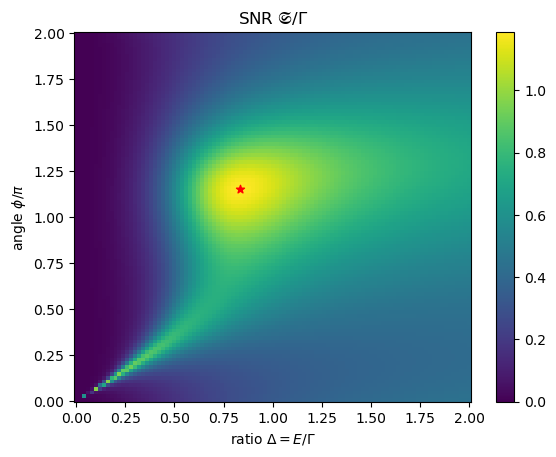

In [50]:
energies = np.linspace(0,2,101)
angles = np.linspace(0.005,2-0.005,101)
SNRs = np.zeros((len(angles), len(energies)))

for idx_1, energy in enumerate(energies):
    for idx_2, angle in enumerate(angles):
        SNRs[idx_2,idx_1] = qubit_clock_SNR([energy,angle])
        
# let us optimize the single qubit clock:
min_pars = fmin(neg_qubit_clock_SNR,[1,1])
min_value = neg_qubit_clock_SNR(min_pars)

#colorpalette
my_cmap = sns.color_palette('viridis', as_cmap=True)

fig, ax = plt.subplots()
im = ax.pcolormesh(energies, angles, SNRs,norm='linear',cmap=my_cmap)
#plt.hlines(1,-1,1, color='black', linestyles='dashed')
ax.set_xlabel(r'ratio $\Delta = E/\Gamma$')
ax.set_ylabel(r'angle $\phi/\pi$')
#ax.set_yticks([0,0.25,0.5,0.75,1,1.25,1.5,1.75,2],labels=[0,0.25,0.5,0.75,1,1.25,1.5,1.75,2])
ax.set_title(r'SNR $\mathfrak{S}/\Gamma$')
ax.scatter(min_pars[0],min_pars[1], color='red', marker='*')
fig.colorbar(im, ax=ax)

print(r'The maximum SNR (%g) is reached at an energy of %g and an angle of  %g \pi'%(-min_value,min_pars[0],min_pars[1]))

# Two Qubit Clockworks with Feedback

In [ ]:
Projm1 = np.diag([1,0])
Projm2 = np.diag([0,1])
Ketbra12 = np.array([[0,1],[0,0]])
Ketbra21 = np.array([[0,0],[1,0]])

def H1m1(E1):
    return np.kron(H*E1,np.kron(Id(2),Projm1))
def H1m2(E2):
    return np.kron(H*E2,np.kron(Id(2),Projm2))
def H2m1(E2):
    return np.kron(Id(2),np.kron(H*E2,Projm1))
def H2m2(E1):
    return np.kron(Id(2),np.kron(H*E1,Projm2))

def J1m1(phi):
    return np.kron(J_phi(phi), np.kron(Id(2), Projm1))
def J1m2(phi):
    return np.kron(J_phi(phi), np.kron(Id(2), Ketbra12))
def J2m1(phi):
    return np.kron(Id(2), np.kron(J_phi(phi), Ketbra21))
def J2m2(phi):
    return np.kron(Id(2), np.kron(J_phi(phi), Projm2))

def construct_Lioville_and_current_op_list_under_2qubitfeedback(E1,E2,phi):
    H = H1m1(E1) + H1m2(E2) + H2m1(E2) + H2m2(E1)
    Lioville = calc_Liouville(H, [J1m1(phi),J1m2(phi),J2m1(phi),J2m2(phi)])
    current_op_list = [calc_jump_channel(J1m1(phi)),calc_jump_channel(J1m2(phi)),calc_jump_channel(J2m1(phi)),calc_jump_channel(J2m2(phi))]

    return Lioville, current_op_list

def SNR_under_2qubitfeedback(x):
    # x[0]: alpha_1
    # x[1]: alpha_2
    Liouville, Jump_op_list = construct_Lioville_and_current_op_list_under_2qubitfeedback(x[0]*min_pars[0],x[1]*min_pars[0],min_pars[1])
    _,_, SNR = evaluate_SNR(Liouville,Jump_op_list,[1,1,1,1])
    return SNR

def neg_SNR_under_2qubitfeedback(x):
    return -SNR_under_2qubitfeedback(x)

In [46]:
min_pars_2qubitfeedback = fmin(neg_SNR_under_2qubitfeedback,[0.93,1.02])
max_value_2qubitfeedback = SNR_under_2qubitfeedback(min_pars_2qubitfeedback)
print(r'The maximum SNR (%g) is reached at $\alpha_1=$ %g and $\alpha_2=$ %g'%(max_value_2qubitfeedback,min_pars_2qubitfeedback[0],min_pars_2qubitfeedback[1]))

Optimization terminated successfully.
         Current function value: -2.593489
         Iterations: 30
         Function evaluations: 59
The maximum SNR (2.59349) is reached at $\alpha_1=$ 1.19621 and $\alpha_2=$ 0.881738


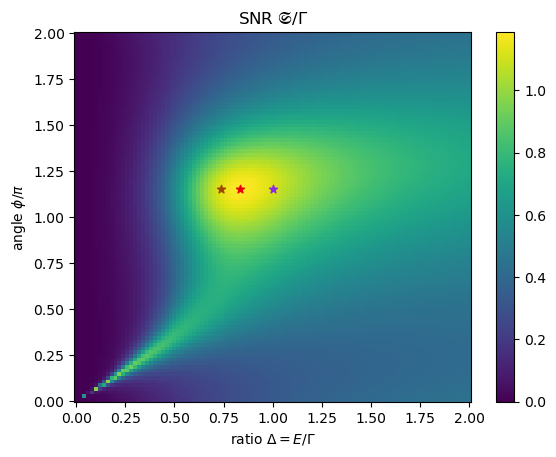

In [74]:
color_list = sns.color_palette("bright")

fig, ax = plt.subplots()
im = ax.pcolormesh(energies, angles, SNRs,norm='linear',cmap=my_cmap)
ax.set_xlabel(r'ratio $\Delta = E/\Gamma$')
ax.set_ylabel(r'angle $\phi/\pi$')
ax.set_title(r'SNR $\mathfrak{S}/\Gamma$')
ax.scatter(min_pars[0],min_pars[1], color=color_list[3], marker='*')
ax.scatter(min_pars[0]*(min_pars_2qubitfeedback[0]),min_pars[1], color=color_list[4], marker='*')
ax.scatter(min_pars[0]*(min_pars_2qubitfeedback[1]),min_pars[1], color=color_list[5], marker='*')
fig.colorbar(im, ax=ax)

plt.savefig('qubit_clockwork_Python_SNR.png',dpi=600)

In [87]:
Alpha1s = np.linspace(0.25,2.25,101)
Alpha2s = np.linspace(0.25,1.75,101)
SNRs_feedback_landscape = np.zeros((len(Alpha2s), len(Alpha1s)))

for idx_1, alpha1 in enumerate(Alpha1s):
    for idx_2, alpha2 in enumerate(Alpha2s):
        SNRs_feedback_landscape[idx_2,idx_1] = SNR_under_2qubitfeedback([alpha1,alpha2])

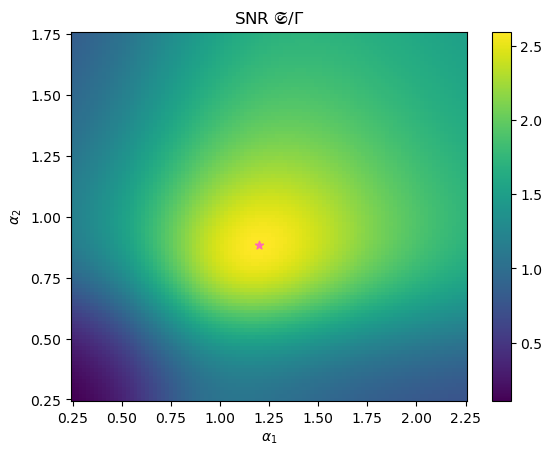

In [89]:
fig, ax = plt.subplots()
im = ax.pcolormesh(Alpha1s, Alpha2s, SNRs_feedback_landscape, norm='linear',cmap=my_cmap)
ax.set_xlabel(r'$\alpha_1$')
ax.set_ylabel(r'$\alpha_2$')
ax.set_yticks([0.25,0.5,0.75,1,1.25,1.5,1.75])
ax.set_title(r'SNR $\mathfrak{S}/\Gamma$')
ax.scatter(min_pars_2qubitfeedback[0],min_pars_2qubitfeedback[1], color='hotpink', marker='*')
fig.colorbar(im, ax=ax)

plt.savefig('qubit_clockwork_feedback_landscape_Python_SNR.png',dpi=600)